##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [ ]:
import sys
import types
import os

if 'pkg_resources' not in sys.modules:
    pkg_resources = types.ModuleType('pkg_resources')
    sys.modules['pkg_resources'] = pkg_resources
    pkg_resources.parse_version = lambda x: x
    print("Mocked pkg_resources successfully.")

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

model_path = r"C:\Users\A\Desktop\Fatimah\New folder\mask-rcnn-inception-resnet-v2-tensorflow2-1024x1024-v1"
image_dir = r"C:\Users\A\Desktop\Fatimah\New folder\test_images"

print("Loading model...")
detector = hub.load(model_path)
print("Model loaded successfully!")

Mocked pkg_resources successfully.
Loading model...


Model loaded successfully!


Loading model...
Model loaded successfully!
Analyzing img1.jpg...


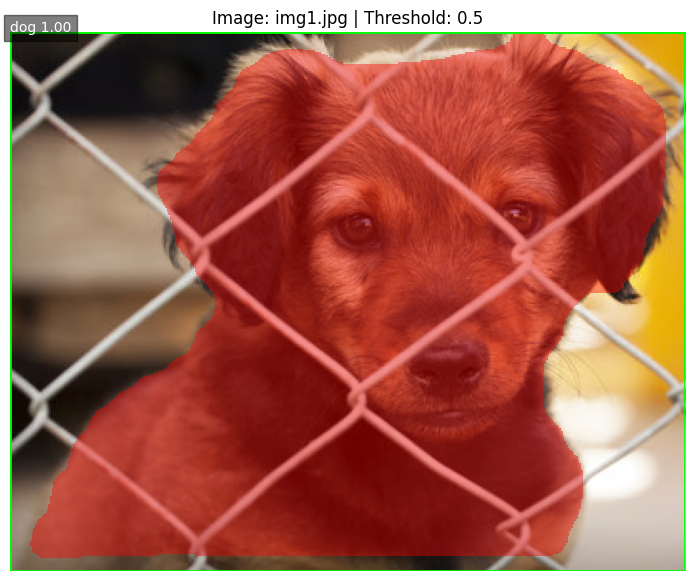

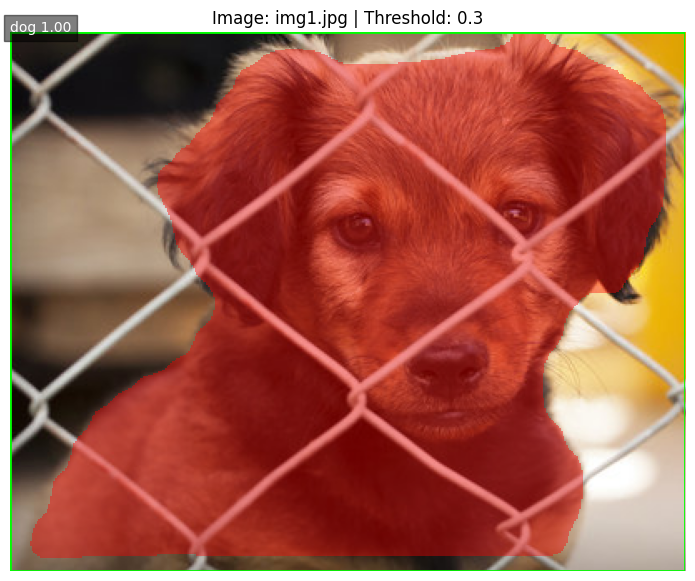

Analyzing img2.jpg...


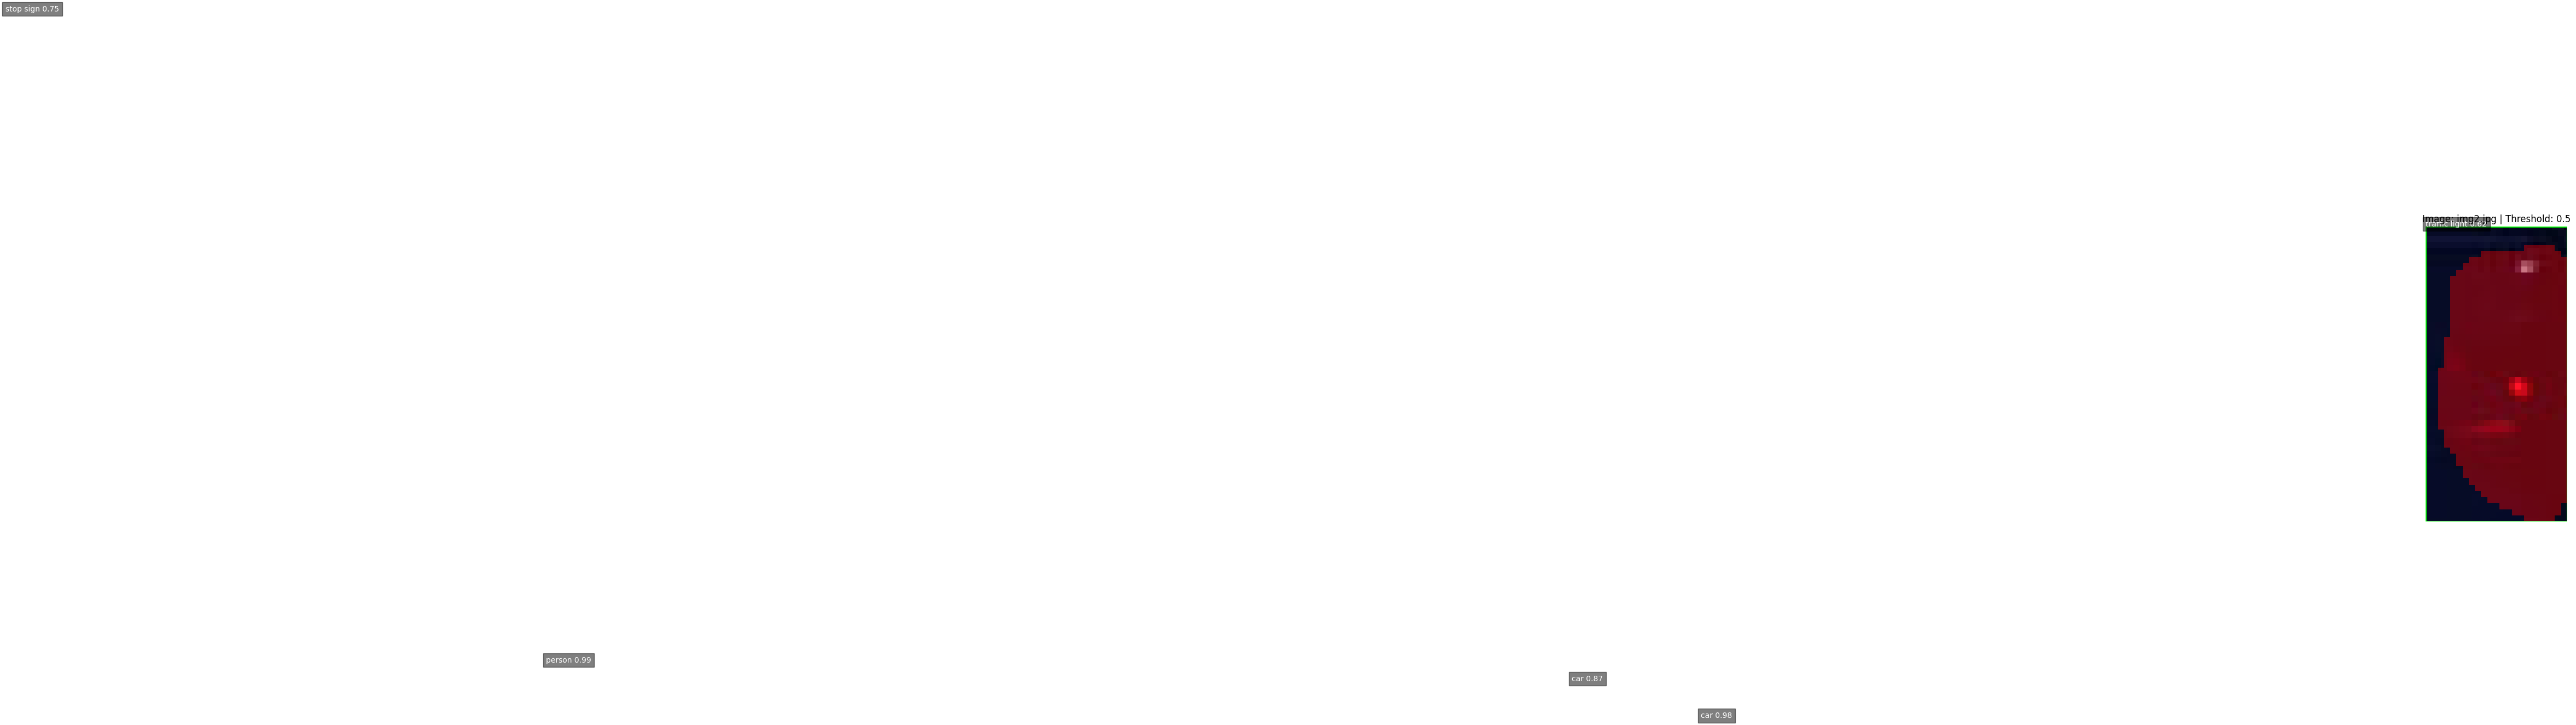

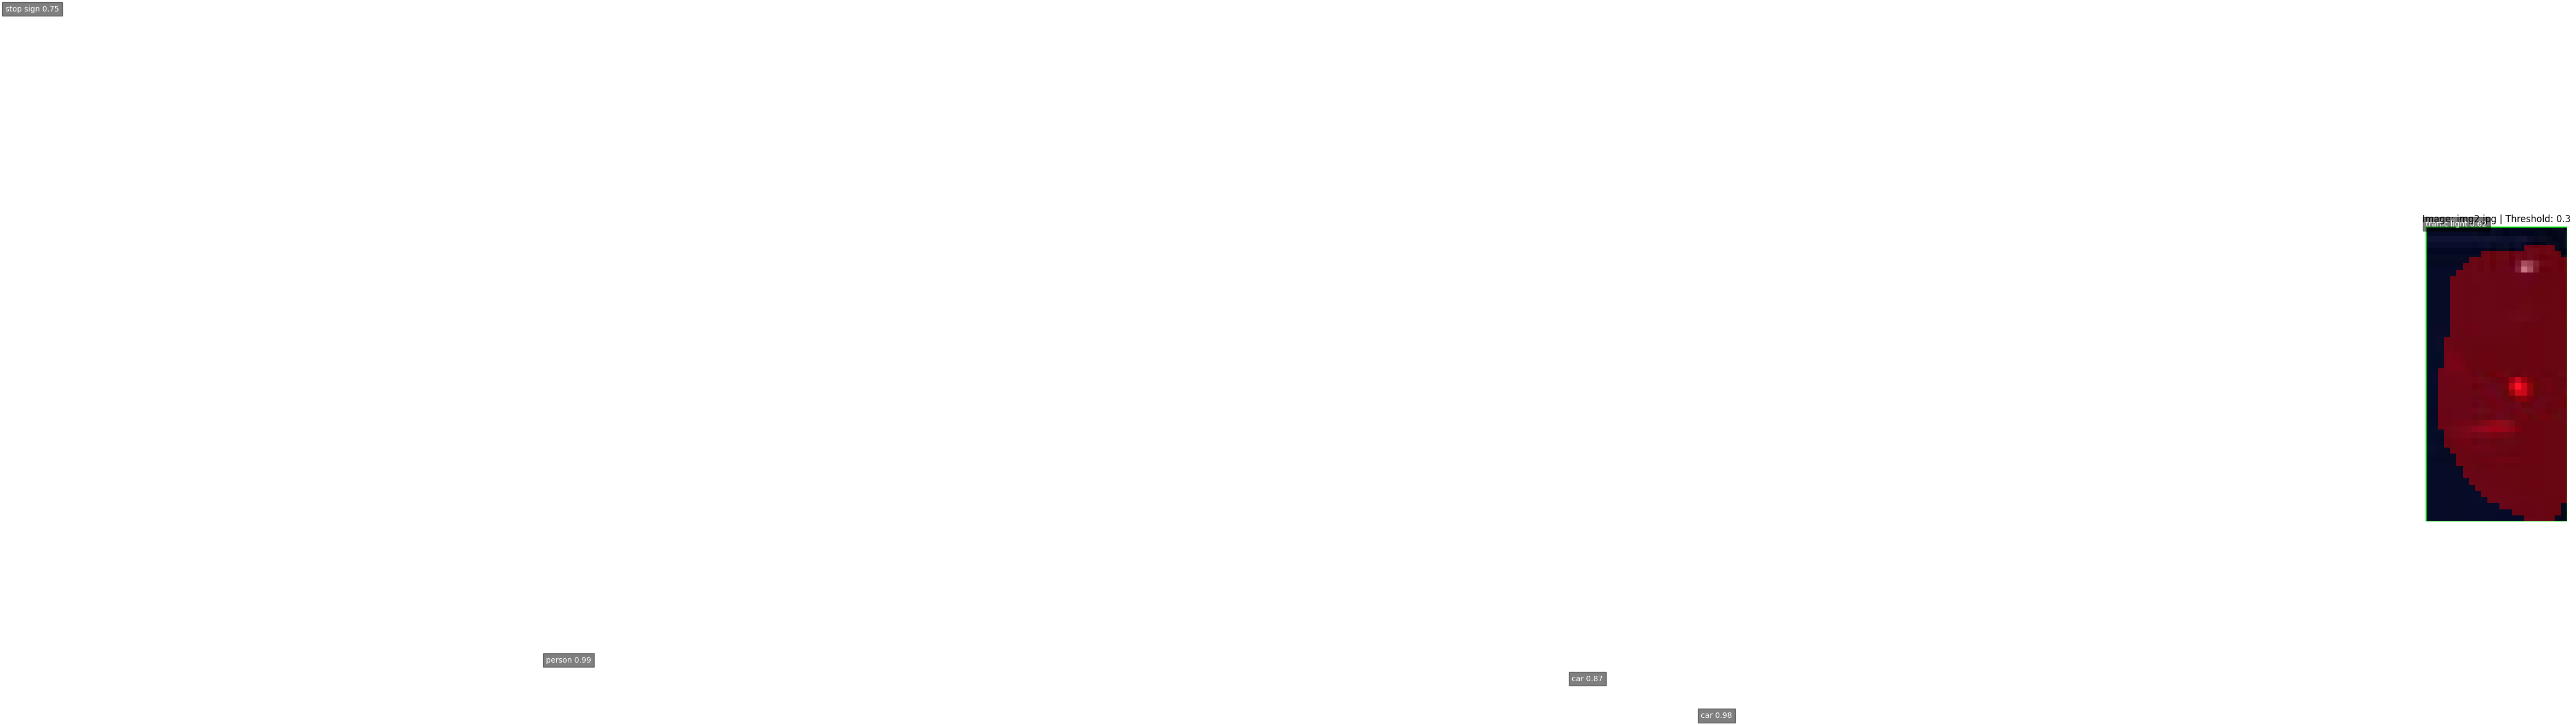

Analyzing img3.jpg...


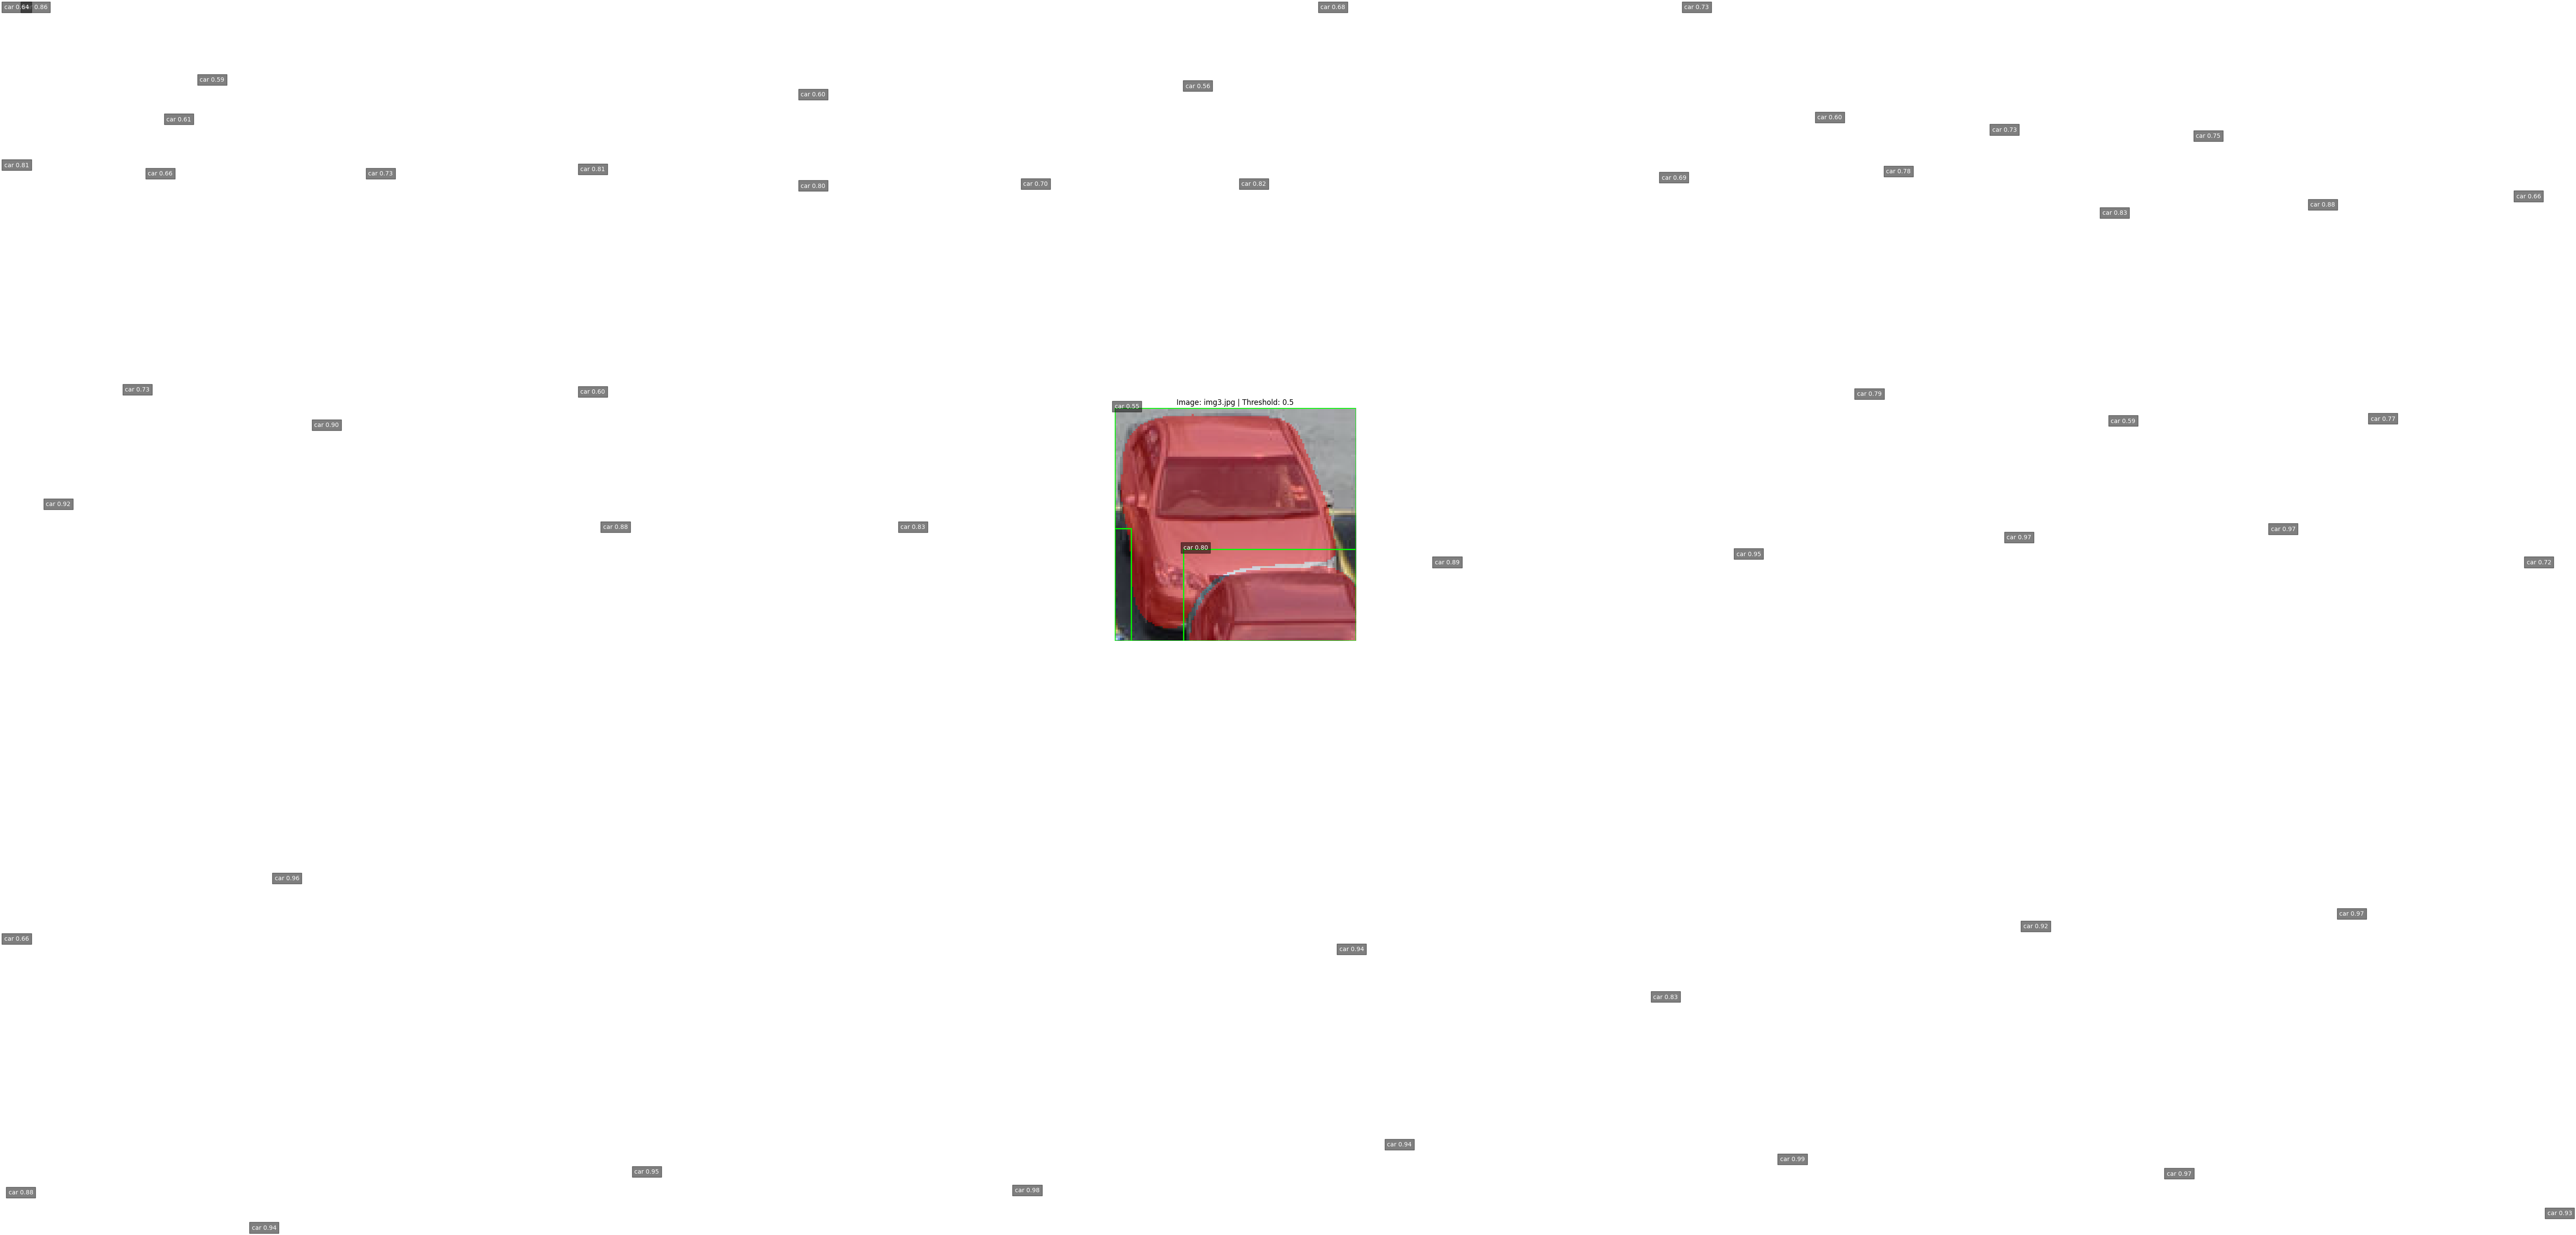

Analyzing img4.jpg...


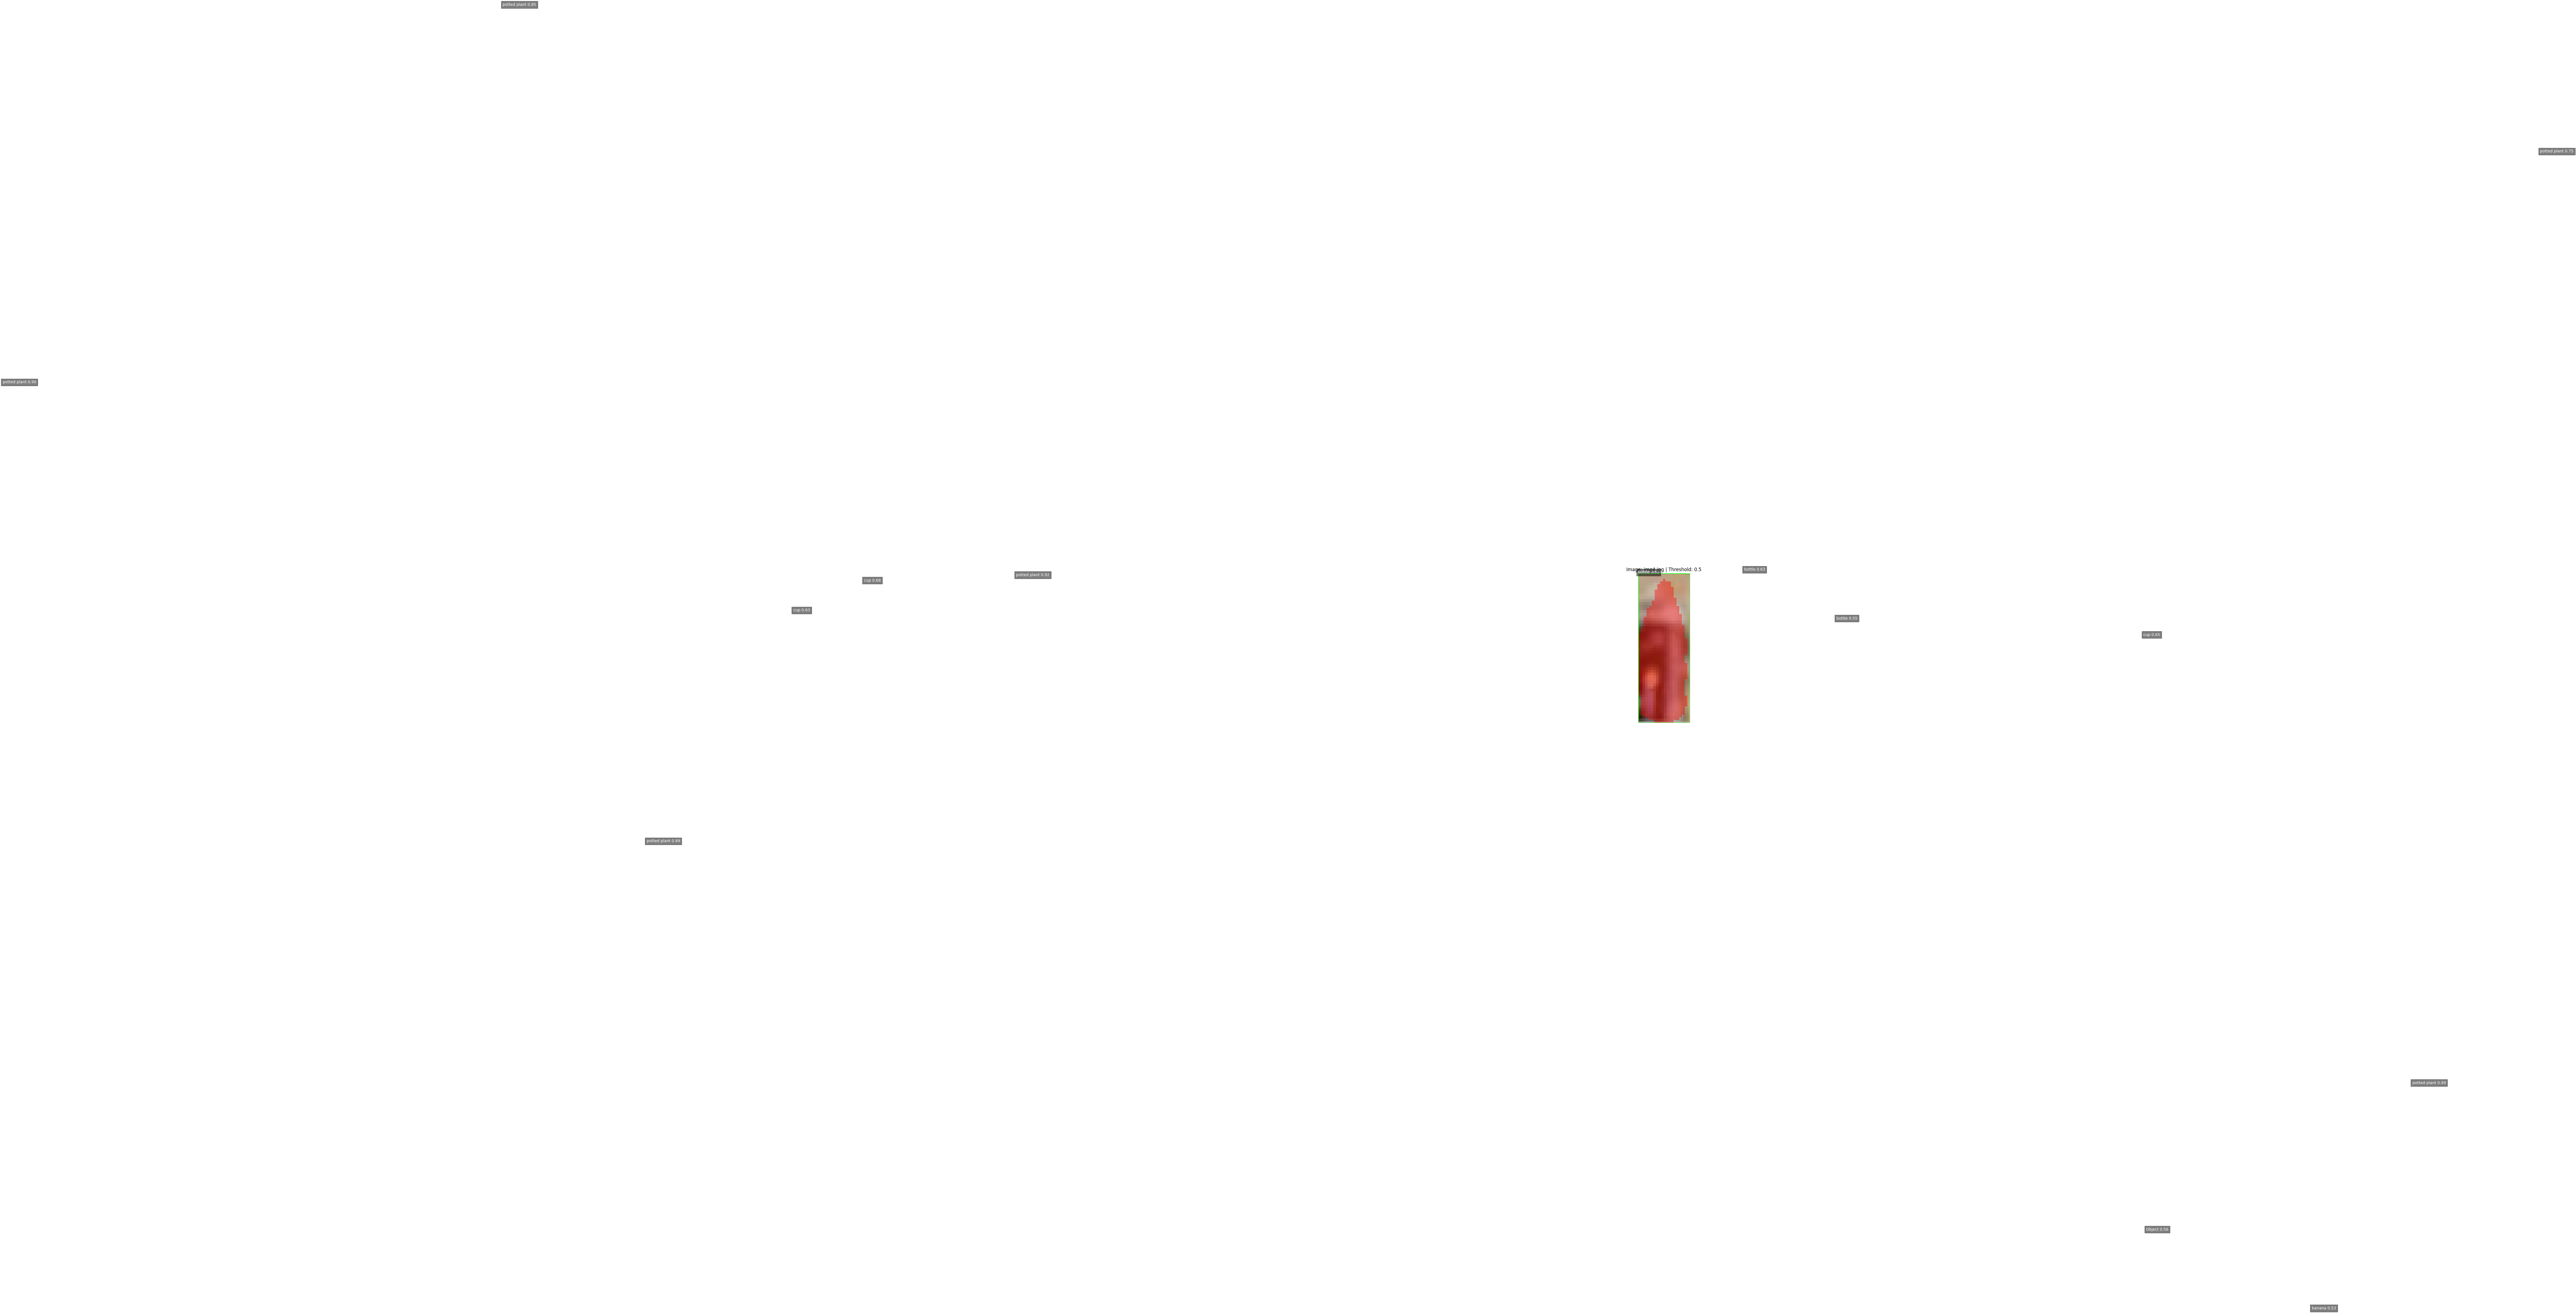

Analyzing img5.jpg...


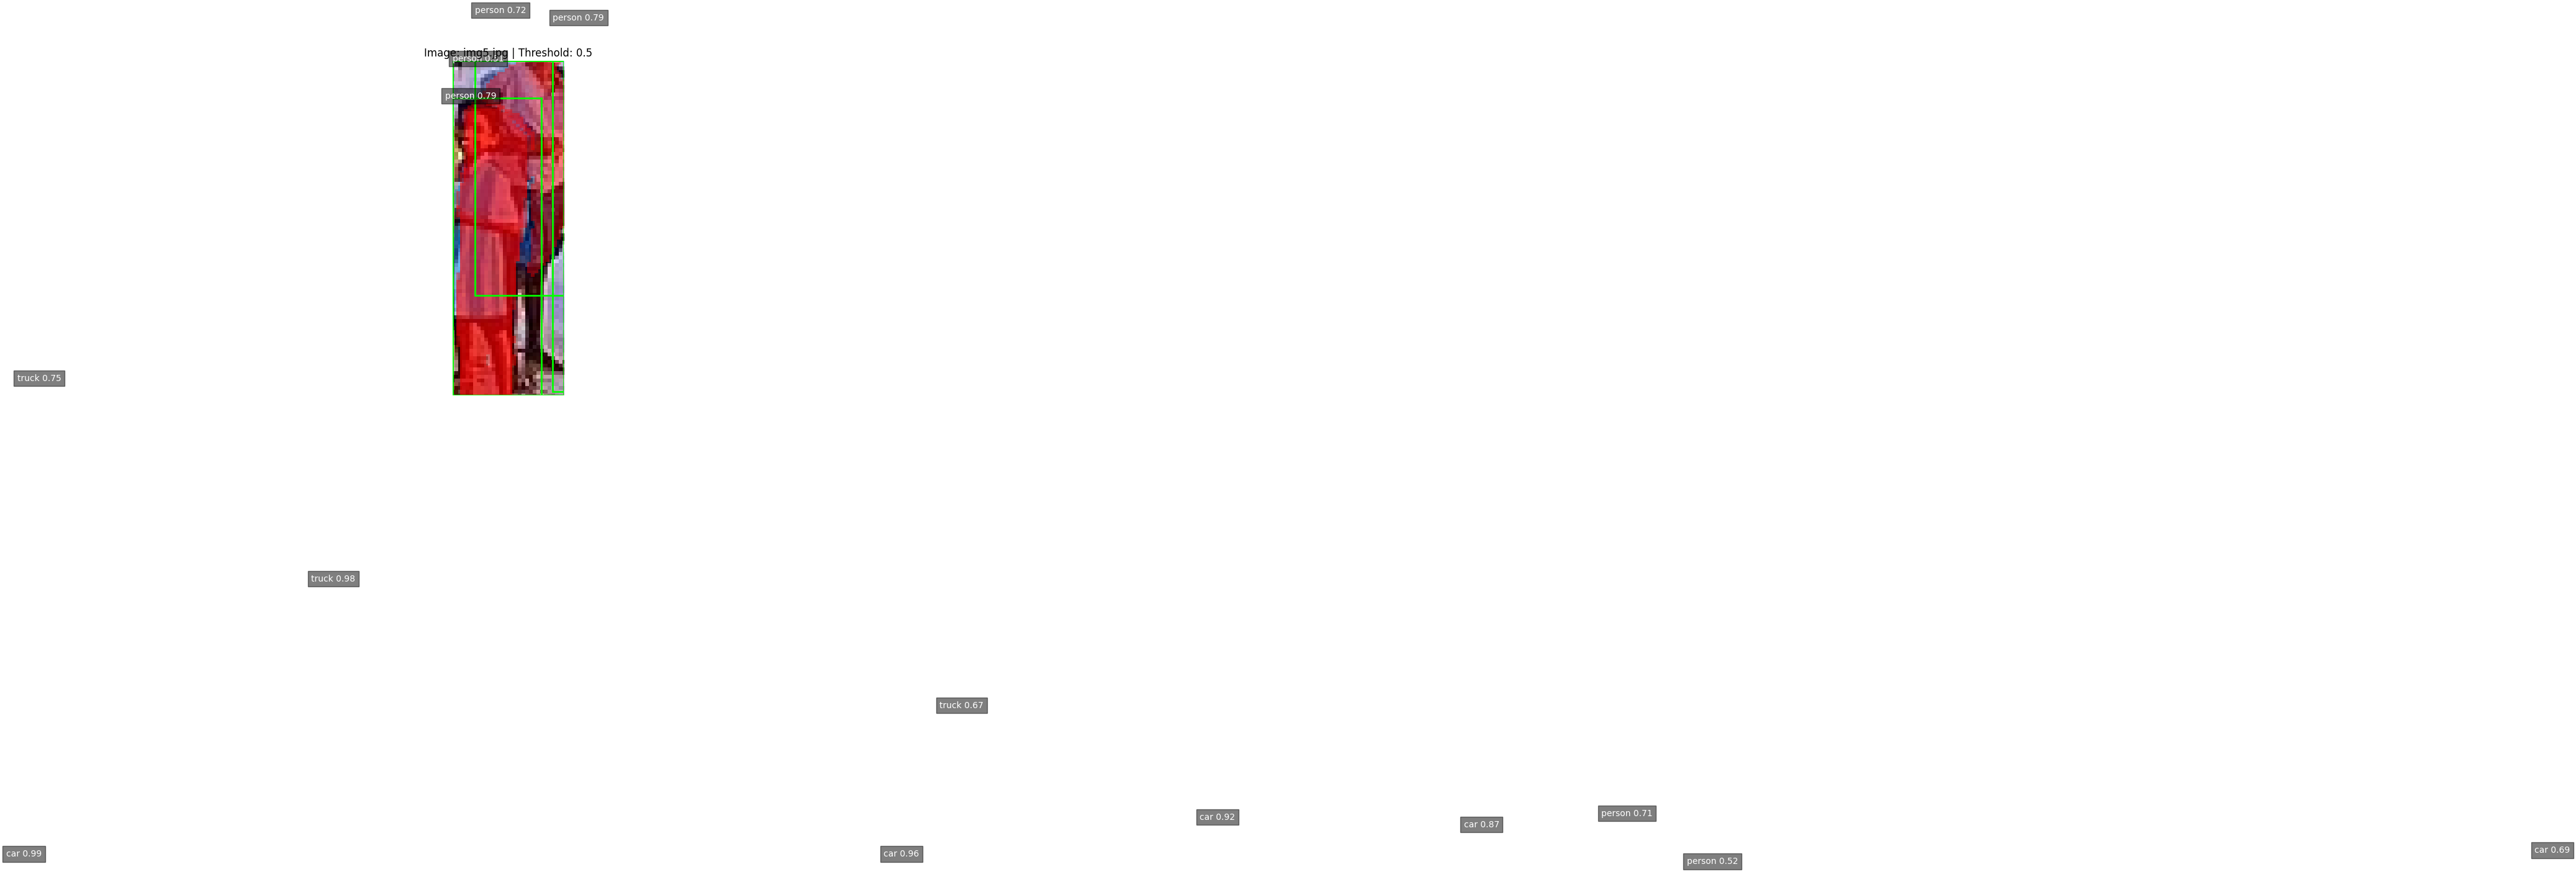

In [ ]:

import sys
import types
import os
import subprocess

if 'pkg_resources' not in sys.modules:
    dummy_pkg = types.ModuleType('pkg_resources')
    sys.modules['pkg_resources'] = dummy_pkg
    dummy_pkg.parse_version = lambda x: x 
    print("Python 3.12 Compatibility Hack Applied.")

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

model_path = r"C:\Users\A\Desktop\Fatimah\New folder\mask-rcnn-inception-resnet-v2-tensorflow2-1024x1024-v1"
image_dir = r"C:\Users\A\Desktop\Fatimah\New folder\test_images"

print("Loading model...")
detector = hub.load(model_path)
print("Model loaded successfully!")

ID_MAPPING = {1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane', 6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light', 13: 'stop sign', 15: 'bench', 16: 'bird', 17: 'cat', 18: 'dog', 31: 'handbag', 32: 'tie', 33: 'suitcase', 44: 'bottle', 47: 'cup', 51: 'bowl', 52: 'banana', 53: 'apple', 62: 'chair', 63: 'couch', 64: 'potted plant', 72: 'tv', 73: 'laptop', 74: 'mouse', 75: 'remote', 76: 'keyboard', 77: 'cell phone', 84: 'book', 85: 'clock', 86: 'vase'}

def run_lab_exercise(image_path, threshold):
    img = Image.open(image_path).convert("RGB")
    image_np = np.array(img)
    input_tensor = tf.convert_to_tensor(image_np)[tf.newaxis, ...]

    results = detector(input_tensor)
    result = {key: value.numpy() for key, value in results.items()}

    scores = result['detection_scores'][0]
    valid = scores > threshold
    
    boxes = result['detection_boxes'][0][valid]
    classes = result['detection_classes'][0][valid].astype(int)
    final_scores = scores[valid]
    masks = result['detection_masks'][0][valid]

    plt.figure(figsize=(10, 7))
    plt.imshow(image_np)
    ax = plt.gca()
    h, w, _ = image_np.shape

    for i in range(len(boxes)):
        ymin, xmin, ymax, xmax = boxes[i]
        
        
        left, right = int(xmin * w), int(xmax * w)
        top, bottom = int(ymin * h), int(ymax * h)
        target_w, target_h = right - left, bottom - top

        if target_w <= 0 or target_h <= 0: continue
        
        
        rect = patches.Rectangle((left, top), target_w, target_h, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

        
        label = f"{ID_MAPPING.get(classes[i], 'Object')} {final_scores[i]:.2f}"
        plt.text(left, top, label, color='white', bbox=dict(facecolor='black', alpha=0.5))

        mask = masks[i]
        mask_resized = np.array(Image.fromarray((mask * 255).astype(np.uint8)).resize((target_w, target_h)))
        
        overlay = np.zeros((target_h, target_w, 4))
        overlay[:, :, 0] = 1.0 
        overlay[:, :, 3] = (mask_resized > 128) * 0.4 
        
        ax.imshow(overlay, extent=(left, right, bottom, top), interpolation='nearest')

    plt.title(f"Image: {os.path.basename(image_path)} | Threshold: {threshold}")
    plt.axis('off')
    plt.show()

image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

for img_name in image_files[:5]:
    path = os.path.join(image_dir, img_name)
    print(f"Analyzing {img_name}...")
    run_lab_exercise(path, 0.5)
    run_lab_exercise(path, 0.3)
    